# CNN People Counter — Colab Version
Train a CNN to estimate **how many people live in a picture** (200×200 px).  
Target is extracted from the **last number in each filename** (e.g. `house_district5_3.jpg` → target = **3**).

In [2]:
# ── Cell 1: Mount Drive & Unzip ───────────────────────────────
# Only needs to run once per session. Comment out after first run.
# from google.colab import drive
# drive.mount('/content/drive')

# !unzip -q /content/drive/MyDrive/AppML/jpegs_all_300m.zip -d /content/Data_300
print('Done unzipping')

import os
print(f'Files in Data_300: {len(os.listdir("/content/Data_300"))}')

Done unzipping
Files in Data_300: 9587


In [2]:
# ── Cell 2: Imports ───────────────────────────────────────────
import os
import re
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from PIL import Image
from sklearn.metrics import mean_absolute_error, r2_score
from tqdm.auto import tqdm

print(f'PyTorch {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

PyTorch 2.11.0+cu128
Using device: cuda


In [3]:
!nvidia-smi

Tue Jun  2 13:14:03 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   61C    P0             29W /   70W |    2993MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [12]:
# ── Cell 3: Config ────────────────────────────────────────────
DATA_DIR    = '/content/Data_300'
IMG_SIZE    = 200
BATCH_SIZE  = 32
NUM_SAMPLES = -1        # -1 = use all
EPOCHS      = 20
LR          = 1e-3
VAL_SPLIT   = 0.2
DROPOUT     = 0.3
PATIENCE    = 10
OUTPUT_DIR  = '/content/output'
SEED        = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed()

In [13]:
# ── Cell 4: Dataset ───────────────────────────────────────────
def extract_target_from_filename(filename: str) -> int:
    stem = Path(filename).stem
    numbers = re.findall(r'\d+', stem)
    if not numbers:
        raise ValueError(f'No numeric target found in filename: {filename}')
    return int(numbers[-1])


class PeopleCountDataset(Dataset):
    VALID_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}

    def __init__(self, root_dir: str, transform=None):
        self.root_dir = Path(root_dir)
        self.transform = transform
        self.samples = []

        for f in sorted(self.root_dir.iterdir()):
            if f.suffix.lower() in self.VALID_EXT:
                try:
                    target = extract_target_from_filename(f.name)
                    self.samples.append((f, target))
                except ValueError:
                    print(f'  ⚠ Skipping {f.name} — no target in name')

        if not self.samples:
            raise FileNotFoundError(f'No valid images in {root_dir}.')

        targets = [t for _, t in self.samples]
        print(f'✓ Loaded {len(self.samples)} images')
        print(f'  Target range: {min(targets)} – {max(targets)}  '
              f'(mean {np.mean(targets):.1f}, std {np.std(targets):.1f})')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, target = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(target, dtype=torch.float32)

In [14]:
# ── Cell 5: Transforms ────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

In [ ]:
# ── Cell 6: Load & Balance Dataset ───────────────────────────
full_dataset = PeopleCountDataset(DATA_DIR, transform=None)
if NUM_SAMPLES > 0:
    full_dataset.samples = full_dataset.samples[:NUM_SAMPLES]

# Balance: equal zero-people vs has-people samples
zero_samples    = [s for s in full_dataset.samples if s[1] == 0]
nonzero_samples = [s for s in full_dataset.samples if s[1] > 0]
n_balanced = min(len(zero_samples), len(nonzero_samples))
random.shuffle(zero_samples)
random.shuffle(nonzero_samples)
full_dataset.samples = zero_samples[:n_balanced] + nonzero_samples[:n_balanced]
random.shuffle(full_dataset.samples)
print(f'Balanced: {n_balanced} zero-people + {n_balanced} with-people = {len(full_dataset.samples)} total')

val_size   = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size
train_subset, val_subset = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

train_dataset = PeopleCountDataset(DATA_DIR, transform=train_transform)
train_dataset.samples = [full_dataset.samples[i] for i in train_subset.indices]

val_dataset = PeopleCountDataset.__new__(PeopleCountDataset)
val_dataset.root_dir = full_dataset.root_dir
val_dataset.transform = val_transform
val_dataset.samples = [full_dataset.samples[i] for i in val_subset.indices]

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

print(f'Train: {len(train_dataset)} samples  |  Val: {len(val_dataset)} samples')

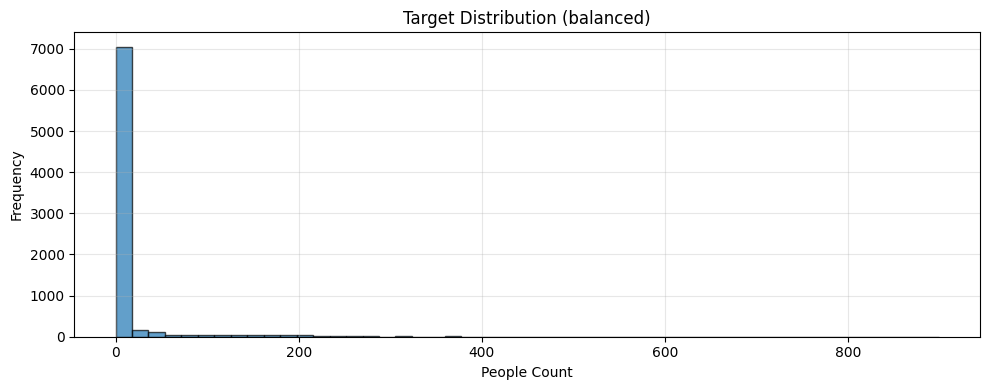

In [16]:
# ── Cell 7: EDA — Target Distribution ────────────────────────
all_targets = [t for _, t in full_dataset.samples]
plt.figure(figsize=(10, 4))
plt.hist(all_targets, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('People Count')
plt.ylabel('Frequency')
plt.title('Target Distribution (balanced)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [17]:
# ── Cell 8: Model ─────────────────────────────────────────────
class PeopleCountCNN(nn.Module):
    def __init__(self, dropout=0.3):
        super().__init__()

        def conv_block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_c, out_c, kernel_size=3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        self.features = nn.Sequential(
            conv_block(3, 32),    # 200 → 100
            conv_block(32, 64),   # 100 → 50
            conv_block(64, 128),  #  50 → 25
            conv_block(128, 256), #  25 → 12
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(128, 1),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        return self.regressor(x).squeeze(-1)


model = PeopleCountCNN(dropout=DROPOUT).to(device)
total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {total_params:,}')

Model parameters: 1,207,201


In [18]:
# ── Cell 9: Loss / Optimizer / Scheduler ─────────────────────
criterion = nn.MSELoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

In [19]:
# ── Cell 10: Train / Eval Functions ──────────────────────────
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    all_preds, all_targets = [], []

    for imgs, targets in tqdm(loader, desc='  Training', leave=False):
        imgs, targets = imgs.to(device), targets.to(device)
        optimizer.zero_grad()
        preds = model(imgs)
        loss = criterion(preds, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        all_preds.extend(preds.detach().cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

    return running_loss / len(loader.dataset), mean_absolute_error(all_targets, all_preds)


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    all_preds, all_targets = [], []

    for imgs, targets in loader:
        imgs, targets = imgs.to(device), targets.to(device)
        preds = model(imgs)
        loss = criterion(preds, targets)
        running_loss += loss.item() * imgs.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    mae = mean_absolute_error(all_targets, all_preds)
    r2  = r2_score(all_targets, all_preds) if len(set(all_targets)) > 1 else 0.0
    return epoch_loss, mae, r2, np.array(all_preds), np.array(all_targets)

In [20]:
# ── Cell 11: Training Loop ────────────────────────────────────
best_val_loss    = float('inf')
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}

pbar = tqdm(range(1, EPOCHS + 1), desc='Training')

for epoch in pbar:
    train_loss, train_mae = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_mae, val_r2, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_mae'].append(train_mae)
    history['val_mae'].append(val_mae)

    pbar.set_postfix({
        't_loss': f'{train_loss:.4f}',
        'v_loss': f'{val_loss:.4f}',
        'v_mae':  f'{val_mae:.2f}',
        'v_r2':   f'{val_r2:.3f}',
    })

    if val_loss < best_val_loss:
        best_val_loss    = val_loss
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': val_loss,
            'val_mae':  val_mae,
        }, os.path.join(OUTPUT_DIR, 'best_model.pth'))
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f'\n⏹ Early stopping at epoch {epoch}')
            break

print(f'\n✓ Training complete — best val loss: {best_val_loss:.4f}')

Training:   0%|          | 0/20 [00:00<?, ?it/s]

  Training:   0%|          | 0/196 [00:00<?, ?it/s]

  Training:   0%|          | 0/196 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7c4933fa9760>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()Exception ignored in: 
<function _MultiProcessingDataLoaderIter.__del__ at 0x7c4933fa9760>
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
Traceback (most recent call last):
      File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1709, in __del__
    self._shutdown_workers()if w.is_alive():

  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1692, in _shutdown_workers
      if w.is_alive(): 
       ^ ^ ^ ^ ^^^^^^^^^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^assert self._parent_pid == os.getpid(), 'can only test a child process'^
 
   File "/usr/lib/pyth

  Training:   0%|          | 0/196 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# ── Cell 12: Training Curves ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2)
axes[0].plot(history['val_loss'],   label='Val Loss',   linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].set_title('Loss Curves'); axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history['train_mae'], label='Train MAE', linewidth=2)
axes[1].plot(history['val_mae'],   label='Val MAE',   linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('MAE')
axes[1].set_title('MAE Curves'); axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()

In [ ]:
# ── Cell 13: Final Evaluation ─────────────────────────────────
ckpt = torch.load(os.path.join(OUTPUT_DIR, 'best_model.pth'),
                  map_location=device, weights_only=True)
model.load_state_dict(ckpt['model_state_dict'])

val_loss, val_mae, val_r2, preds, targets = evaluate(model, val_loader, criterion)
print(f"Best model from epoch {ckpt['epoch']}:")
print(f'  Val MSE : {val_loss:.4f}')
print(f'  Val MAE : {val_mae:.2f}')
print(f'  Val R²  : {val_r2:.3f}')

In [ ]:
# ── Cell 14: Predicted vs Actual ──────────────────────────────
fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(targets, preds, alpha=0.5, edgecolors='k', linewidth=0.3, s=50)
lims = [min(targets.min(), preds.min()) - 1, max(targets.max(), preds.max()) + 1]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_xlabel('Actual People Count', fontsize=12)
ax.set_ylabel('Predicted People Count', fontsize=12)
ax.set_title('Predicted vs Actual', fontsize=14)
ax.legend(fontsize=11); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'pred_vs_actual.png'), dpi=150)
plt.show()

In [ ]:
# ── Cell 15: Error Analysis ───────────────────────────────────
errors     = preds - targets
abs_errors = np.abs(errors)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(errors, bins=30, edgecolor='black', alpha=0.7, color='#DD8452')
axes[0].set_xlabel('Prediction Error (pred − actual)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Error Distribution')
axes[0].axvline(0, color='red', linestyle='--')

worst_idx = np.argsort(abs_errors)[-10:][::-1]
axes[1].barh(range(len(worst_idx)), abs_errors[worst_idx], color='#C44E52', edgecolor='black')
axes[1].set_xlabel('Absolute Error')
axes[1].set_title('Top 10 Worst Predictions')
for i, idx in enumerate(worst_idx):
    axes[1].text(abs_errors[idx] + 0.1, i,
                 f'actual={targets[idx]:.0f}, pred={preds[idx]:.1f}', va='center')
plt.tight_layout()
plt.show()

print(f'Median absolute error : {np.median(abs_errors):.2f}')
print(f'90th percentile error : {np.percentile(abs_errors, 90):.2f}')
print(f'Within ±1 person      : {(abs_errors <= 1).mean()*100:.1f}%')
print(f'Within ±2 people      : {(abs_errors <= 2).mean()*100:.1f}%')

In [ ]:
# ── Cell 16: Save model to Drive (optional) ───────────────────
import shutil
shutil.copy(
    os.path.join(OUTPUT_DIR, 'best_model.pth'),
    '/content/drive/MyDrive/AppML/best_model_data300.pth'
)
print('Model saved to Drive')